## Датасет Credit Card Fraud Detection.
Практический проект по построению системы поиска аномалий.

### Часть 0. Подготовка

In [1]:
# Инициализация и логирование
import os
import umap
import torch
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from IPython.display import display
from sklearn.svm import OneClassSVM
from sklearn.neighbors import KernelDensity
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

debug = 0  # 1 — выводить отладочные логи, 0 — скрывать
warnings.filterwarnings("ignore", message=".*n_jobs value 1 overridden.*")

In [2]:
# Полезные функции

def log(message):
    if debug == 1:
        # %Y-%m-%d — дата, %H:%M:%S — время
        timestamp = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")
        print(f"[DEBUG] {timestamp} {message}")

log("Функция log готова. Использование: log(message), будет отображено при включенной отладке.")

def show(df):
    if df is None or df.empty:
        log("Ошибочный вызов show(): датафрейм пуст.")
        return
    df_show = df.iloc[0:5].copy()
    if 'name' in df_show.columns:
        df_show['name'] = "Данные скрыты"
    display(df_show)

log("Функция show готова. Использование: show(df), значения в столбце name будут скрыты, отображена таблица с примером наполнения.")

def load_excel_file(file_path):
    try:
        # Проверяем, является ли путь директорией (папкой)
        if os.path.isdir(file_path):
            log(f"Указан путь к папке. Ищем файлы внутри: {file_path}")
            valid_files = [f for f in os.listdir(file_path) if f.endswith(('.csv', '.xlsx', '.xls'))]
            
            if not valid_files:
                log(f"Ошибка: В папке {file_path} не найдено файлов .csv или .xlsx")
                return None
            
            # Берем первый найденный файл, как в вашем примере files[0]
            chosen_file = valid_files[0]
            log(f"Автоматически выбран файл: {chosen_file}")
            file_path = os.path.join(file_path, chosen_file)

        # ---------------------------------------------------------
        # Умное чтение с определением индекса Kaggle / тех. колонок
        # ---------------------------------------------------------
        # Читаем только первые 2 строки, чтобы быстро проверить имена колонок
        if file_path.endswith('.csv'):
            preview = pd.read_csv(file_path, nrows=2)
        else:
            preview = pd.read_excel(file_path, nrows=2)
            
        first_col = preview.columns[0]
        
        # Если первая колонка безымянная (Unnamed) или явно техническая (id, index)
        if "unnamed" in first_col.lower() or first_col.lower() in ['id', 'index', 'uuid']:
            log(f"Обнаружена индексная колонка '{first_col}'. Загружаем с index_col=0.")
            kwargs = {'index_col': 0}
        else:
            kwargs = {}

        # Финальная загрузка всего файла
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path, **kwargs)
        else:
            df = pd.read_excel(file_path, **kwargs)
        # ---------------------------------------------------------
        
        # Приводим оставшиеся колонки к нижнему регистру и убираем пробелы
        df.columns = [str(col).lower().strip() for col in df.columns]
        
        # Обрабатываем строковые значения
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.strip()
                df[col] = df[col].replace({'nan': None, 'null': None, 'None': None, '': None})
        
        log(f"Успешно загружено {len(df)} строк из файла: {file_path}")
        log(f"Колонки: {list(df.columns)}")
        return df
        
    except Exception as e:
        log(f"Ошибка при загрузке файла/папки {file_path}: {e}")
        return None

log("Функция load_excel_file готова. Использование: load_excel_file(путь к файлу). Возвращает df.")



In [3]:
# Функции анализа и EDA

# Определяет имя целевой переменной (автоматически или вручную)
def detect_target(df, target_col=None):
    if target_col is not None:
        target_clean = str(target_col).lower().strip()
        if target_clean in df.columns:
            log(f"Целевая переменная установлена вручную: '{target_clean}'")
            return target_clean
        else:
            log(f"Предупреждение: Указанная колонка '{target_col}' не найдена в DF.")
            
    # Ключевые слова для автоопределения
    target_keywords = ['class', 'target', 'default', 'churn', 'response', 'disposition', 'output']
    for col in df.columns:
        if col in target_keywords:
            log(f"Целевая переменная обнаружена автоматически: '{col}'")
            return col
            
    log("Целевая переменная не обнаружена.")
    return None


# Универсальный быстрый взгляд на структуру данных.  Разделяет признаки по типам и считает пропуски.
def fast_look(df, target_col=None):
    if df is None:
        return
        
    log("Запуск быстрого анализа структуры датафрейма (fast_look)...")
    total_rows = len(df)
    summary_data = []
    
    # Сначала выведем инфо о таргете, если он есть
    if target_col and target_col in df.columns:
        print("\n" + "="*25 + f" АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ: {target_col.upper()} " + "="*25)
        val_counts = df[target_col].value_counts(dropna=False)
        val_pct = df[target_col].value_counts(dropna=False, normalize=True) * 100
        target_info = pd.DataFrame({'Количество': val_counts, 'Процент (%)': val_pct.round(2)})
        display(target_info)
    
    for col in df.columns:
        if col == target_col:
            continue
            
        null_count = df[col].isnull().sum()
        null_pct = (null_count / total_rows) * 100
        unique_count = df[col].nunique()
        dtype = df[col].dtype
        
        if unique_count == 2:
            feat_type = 'Бинарный'
        elif np.issubdtype(dtype, np.number):
            feat_type = 'Числовой'
        elif isinstance(dtype, pd.DatetimeTZDtype) or np.issubdtype(dtype, np.datetime64):
            feat_type = 'Дата/Время'
        else:
            feat_type = 'Текстовый/Категориальный'
            
        summary_data.append({
            'Признак': col,
            'Тип данных': str(dtype),
            'Категория': feat_type,
            'Уникальных': unique_count,
            'Пропусков (кол-во)': null_count,
            'Пропусков (%)': round(null_pct, 2)
        })
        
    summary_df = pd.DataFrame(summary_data)
    
    print("\n" + "="*25 + " СВОДНАЯ СТАТИСТИКА ПО ПРИЗНАКАМ " + "="*25)
    display(summary_df)
    
    print("\n" + "="*25 + " ОПИСАТЕЛЬНАЯ СТАТИСТИКА (ЧИСЛА) " + "="*25)
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
    if numeric_cols:
        display(df[numeric_cols].describe().T)
    
    cat_cols = [c for c in df.select_dtypes(exclude=[np.number]).columns if c != target_col]
    if len(cat_cols) > 0:
        print("\n" + "="*25 + " ОПИСАТЕЛЬНАЯ СТАТИСТИКА (КАТЕГОРИИ) " + "="*25)
        display(df[cat_cols].describe().T)


def plot_correlations(df, target_col=None):
    log("Расчет матрицы корреляций...")
    numeric_df = df.select_dtypes(include=[np.number])
    
    if numeric_df.shape[1] < 2:
        return
        
    corr_matrix = numeric_df.corr()
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap='coolwarm', linewidths=0.1, cbar=True)
    plt.title("Матрица корреляции числовых признаков", fontsize=14)
    plt.show()


def plot_distributions(df, target_col=None, max_cols=6):
    log(f"Построение графиков распределения...")
    # Отбираем признаки для графиков (исключая таргет)
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col][:max_cols]
    
    if len(numeric_cols) == 0:
        return
        
    nrows = (len(numeric_cols) + 1) // 2
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(14, nrows * 3.5))
    axes = axes.flatten()
    
    # Настройка группировки (hue), если таргет бинарный или категориальный (до 10 уникальных значений)
    use_hue = False
    if target_col and df[target_col].nunique() <= 10:
        use_hue = True
    
    for i, col in enumerate(numeric_cols):
        if use_hue:
            # Для сильного дисбаланса классов common_norm=False помогает увидеть форму распределения меньшинства
            sns.histplot(data=df, x=col, hue=target_col, kde=True, ax=axes[i], palette='Set2', common_norm=False)
        else:
            sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue')
            
        axes[i].set_title(f"Распределение: {col}")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# Запуск полного цикла первичного анализа одной командой
def run_full_eda(file_path, target_col=None):
    df = load_excel_file(file_path)
    if df is not None:
        # Пытаемся найти или подтвердить целевую переменную
        detected_target_col = detect_target(df, target_col)
        
        print("\n" + "#"*30 + " ПРИМЕР ДАННЫХ (SHOW) " + "#"*30)
        show(df)
        
        fast_look(df, target_col=detected_target_col)
        plot_correlations(df, target_col=detected_target_col)
        plot_distributions(df, target_col=detected_target_col)
        return df
    else:
        log("Не удалось запустить EDA, так как файл не загружен.")
        return None

In [4]:
# функции анализа аномалий

# Вспомогательный класс для Deep-Learning: Автоэнкодер (PyTorch)
class _AutoencoderNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # Сжатие данных (Representation)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, max(input_dim // 2, 2)),
            nn.ReLU()
        )
        # Восстановление данных
        self.decoder = nn.Sequential(
            nn.Linear(max(input_dim // 2, 2), input_dim)
        )
        
    def forward(self, x):
        return self.decoder(self.encoder(x))

# Основной универсальный пайплайн детекции аномалий
class AdvancedAnomalyPipeline:
    def __init__(self, contamination=0.01, random_state=42, n_clusters=1):
        """
        Инициализация универсального конвейера поиска аномалий.
        
        :param float contamination: Экспертная доля загрязненности датасета (от 0 до 1)
        :param int random_state: Зерно базового генератора случайных чисел
        """
        self.contamination = contamination
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.n_clusters = n_clusters
        
        # 1. Distance-based (K-Means центр масс)
        self.distance_model = KMeans(self.n_clusters, random_state=self.random_state, n_init='auto')
        
        # 2. Density-based (Kernel Density Estimation)
        self.density_model = KernelDensity(kernel='gaussian', bandwidth=0.5)
        
        # 3. Model-based / Линейные методы (One-Class SVM с линейным ядром)
        self.linear_model = OneClassSVM(kernel='linear', nu=self.contamination)
        
        # 4. Model-based / Деревянные методы (Isolation Forest)
        self.tree_model = IsolationForest(contamination=self.contamination, random_state=self.random_state, n_jobs=-1)
        
        # 5. Deep-learning (Autoencoder)
        self.ae_model = None
        self.ae_epochs = 30
        self.ae_batch_size = 256

    def fit(self, X):
        """
        Обучение всех вложенных моделей пайплайна на "хороших" данных.
        
        :param pd.DataFrame X: Матрица признаков для обучения
        """
        # Шаг 0: Защита от Data Leakage через внутреннее масштабирование
        X_scaled = self.scaler.fit_transform(X)
        input_dim = X_scaled.shape[1]
        
        # 1. Обучение Distance-based
        self.distance_model.fit(X_scaled)
        
        # 2. Обучение Density-based (подвыборка для ускорения на больших датасетах)
        sub_size = min(len(X_scaled), 50000)
        idx = np.random.choice(len(X_scaled), sub_size, replace=False)
        self.density_model.fit(X_scaled[idx])
        
        # 3. Обучение Линейного One-Class SVM
        self.linear_model.fit(X_scaled[idx]) # Nu-SVM требователен к O(N^2)
        
        # 4. Обучение Изоляционного леса
        self.tree_model.fit(X_scaled)
        
        # 5. Обучение Deep Learning Автоэнкодера
        self.ae_model = _AutoencoderNet(input_dim)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.ae_model.parameters(), lr=0.005)
        
        tensor_X = torch.FloatTensor(X_scaled)
        dataset = torch.utils.data.TensorDataset(tensor_X)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=self.ae_batch_size, shuffle=True)
        
        self.ae_model.train()
        for epoch in range(self.ae_epochs):
            for batch in dataloader:
                inputs = batch[0]
                optimizer.zero_grad()
                outputs = self.ae_model(inputs)
                loss = criterion(outputs, inputs)
                loss.backward()
                optimizer.step()
                
        return self

    def predict(self, X, strategy='vote', threshold_count=3):
        """
        Предикт аномалий на основе ансамблирования пяти подходов.
        
        :param str strategy: Стратегия объединения: 'vote' (голосование по числу сработавших моделей) или 'all' (логическое И)
        :param int threshold_count: Минимальное количество моделей, зафиксировавших аномалию (для стратегии 'vote')
        :return: Бинарный массив предсказаний (0 - норма, 1 - аномалия)
        :rtype: np.ndarray
        """
        X_scaled = self.scaler.transform(X)
        n_samples = len(X_scaled)
        
        # Создаем матрицу для сбора флагов аномалий от всех 5 методов
        # Строки — наблюдения, столбцы — методы детекции
        votes = np.zeros((n_samples, 5))

        # 1. Расчет Distance-based аномалий
        centroid = self.distance_model.cluster_centers_[0]
        distances = np.linalg.norm(X_scaled - centroid, axis=1)
        thresh_dist = np.percentile(distances, 100 * (1 - self.contamination))
        votes[:, 0] = (distances > thresh_dist).astype(int)

        
        # 2. Расчет Density-based аномалий
        log_densities = self.density_model.score_samples(X_scaled)
        thresh_dens = np.percentile(log_densities, 100 * self.contamination)
        votes[:, 1] = (log_densities < thresh_dens).astype(int)
        
        # 3. Расчет Линейного One-Class SVM
        # sklearn возвращает -1 для аномалий, 1 для нормы
        votes[:, 2] = (self.linear_model.predict(X_scaled) == -1).astype(int)
        
        # 4. Расчет Деревянного метода (Isolation Forest)
        votes[:, 3] = (self.tree_model.predict(X_scaled) == -1).astype(int)
        
        # 5. Расчет Deep-learning (Ошибка восстановления Автоэнкодера)
        self.ae_model.eval()
        with torch.no_grad():
            inputs = torch.FloatTensor(X_scaled)
            outputs = self.ae_model(inputs)
            # Считаем MSE покоординатно для каждого наблюдения
            reconstruction_errors = torch.mean((outputs - inputs) ** 2, dim=1).numpy()
            
        thresh_ae = np.percentile(reconstruction_errors, 100 * (1 - self.contamination))
        votes[:, 4] = (reconstruction_errors > thresh_ae).astype(int)
        
        # Стратегии ансамблирования (Консенсус)
        if strategy == 'vote':
            # Суммируем голоса моделей по строкам
            total_votes = np.sum(votes, axis=1)
            final_predictions = (total_votes >= threshold_count).astype(int)
        elif strategy == 'all':
            # Строгая проверка: аномалия, только если все модели согласны
            final_predictions = np.all(votes == 1, axis=1).astype(int)
        else:
            raise ValueError("Неверная стратегия. Используйте 'vote' или 'all'.")
            
        return final_predictions

### Часть 1. EDA и Preprocessing.


############################## ПРИМЕР ДАННЫХ (SHOW) ##############################


,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



========================= АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ: CLASS =========================


,Количество,Процент (%)
class,,
0,284315,99.83
1,492,0.17



========================= СВОДНАЯ СТАТИСТИКА ПО ПРИЗНАКАМ =========================


,Признак,Тип данных,Категория,Уникальных,Пропусков (кол-во),Пропусков (%)
0,time,float64,Числовой,124592,0,0.0
1,v1,float64,Числовой,275663,0,0.0
2,v2,float64,Числовой,275663,0,0.0
3,v3,float64,Числовой,275663,0,0.0
4,v4,float64,Числовой,275663,0,0.0
5,v5,float64,Числовой,275663,0,0.0
6,v6,float64,Числовой,275663,0,0.0
7,v7,float64,Числовой,275663,0,0.0
8,v8,float64,Числовой,275663,0,0.0
9,v9,float64,Числовой,275663,0,0.0



========================= ОПИСАТЕЛЬНАЯ СТАТИСТИКА (ЧИСЛА) =========================


,count,mean,std,min,25%,50%,75%,max
time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
v1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
v2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
v3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
v4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
v5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
v6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
v7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
v8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
v9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


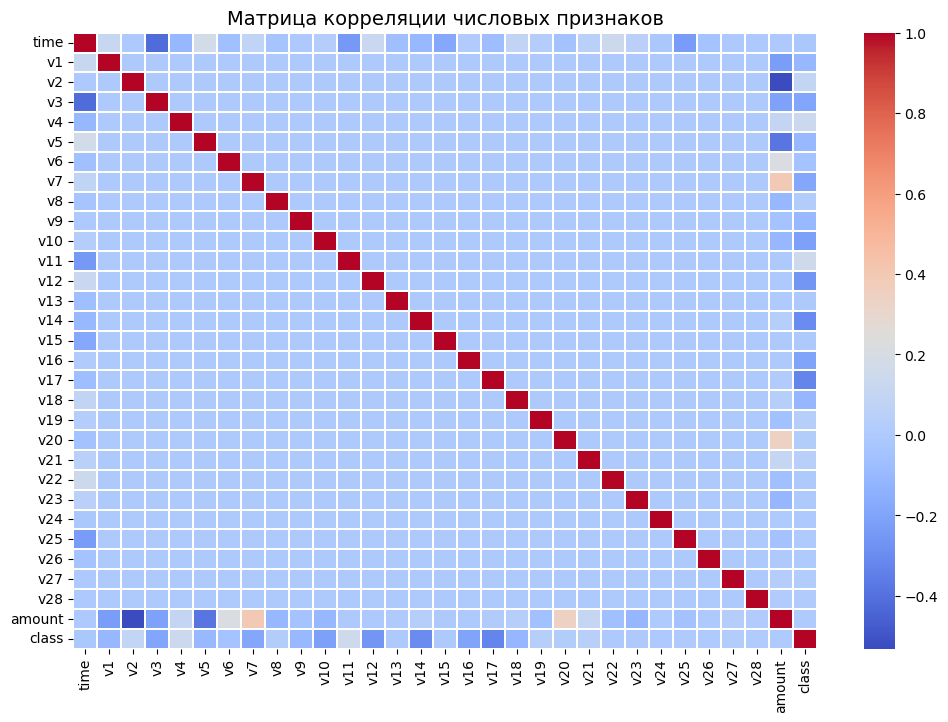

C:\Users\oevlannikov\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


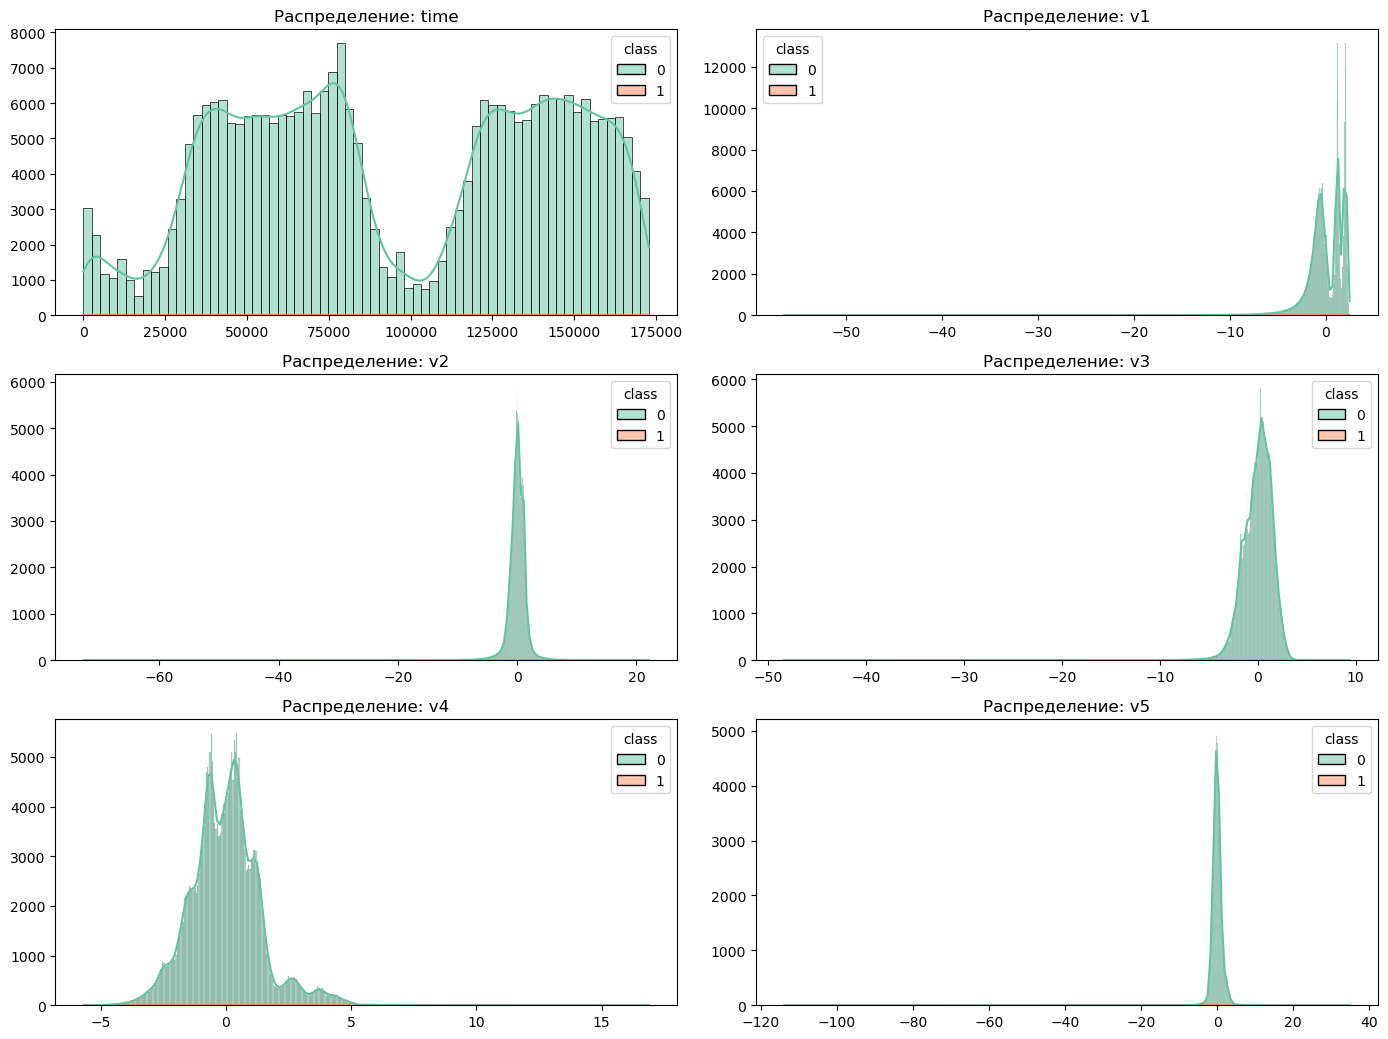

In [5]:
# Загрузка датасета
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

log(f"Path to dataset files: {path}")

df = run_full_eda(path) 

In [6]:
# Выше посчитано автоматически как 0.17%

contamination_rate = df['class'].value_counts(normalize=True)[1]
print(f"Экспертная оценка загрязненности (contamination): {contamination_rate:.5f}")


Экспертная оценка загрязненности (contamination): 0.00173


## Часть 2. Различные модели и алгоритмы.


In [7]:
# 1. Изолируем фичи и таргет
X_data = df.drop(columns=['class', 'pred_iforest', 'pred_lof', 'ensemble_predictions'], errors='ignore')
y_data = df['class']

# 2. Инициализируем пайплайн
log("[START] Инициализация продвинутого пайплайна...")
advanced_pipeline = AdvancedAnomalyPipeline(contamination=contamination_rate, random_state=42, n_clusters=4)
# n_clusters=4 установлено, поскольку UMAP нарисовал 4 кластера, это должно улучшить результаты

# 3. Обучаем
log("[FIT] Обучение пяти математических подходов...")
advanced_pipeline.fit(X_data)

# 4. Предсказываем по мажоритарной схеме голосования 
# (например, три любые модели из пяти должны подтвердить фрод)
log("[PREDICT] Сбор консенсуса моделей...")
df['advanced_ensemble'] = advanced_pipeline.predict(X_data, strategy='vote', threshold_count=3)

# 5. Смотрим результаты    
print("\n" + "="*25 + " РЕЗУЛЬТАТЫ ОЦЕНКИ КАЧЕСТВА " + "="*25)
print("Матрица ошибок (Confusion Matrix):")
print(confusion_matrix(y_data, df['advanced_ensemble']))

print("\nОтчет классификации:")
print(classification_report(y_data, df['advanced_ensemble'], digits=4))


========================= РЕЗУЛЬТАТЫ ОЦЕНКИ КАЧЕСТВА =========================
Матрица ошибок (Confusion Matrix):
[[284038    277]
 [   449     43]]

Отчет классификации:
              precision    recall  f1-score   support

           0     0.9984    0.9990    0.9987    284315
           1     0.1344    0.0874    0.1059       492

    accuracy                         0.9975    284807
   macro avg     0.5664    0.5432    0.5523    284807
weighted avg     0.9969    0.9975    0.9972    284807



## Часть 3. Сжатое представление исходных данных через UMAP

Для снижения потребления ресурсов ноутбука, мы применим стратифицированный даунсэмплинг: возьмем все 492 строки мошенничества и добавим к ним случайные 25 000 строк нормальных транзакций.

In [ ]:
log("Подготовка сэмплированной выборки для UMAP...")

# Забираем ВСЕ аномалии (492 строки)
df_fraud = df[df['class'] == 1]

# Увеличиваем объем легитимных транзакций до 25 000 для плотности
df_normal = df[df['class'] == 0].sample(n=25000, random_state=42)

# Объединяем выборку
df_sub = pd.concat([df_fraud, df_normal])

# Выделяем признаки, убирая таргет и технические колонки предсказаний
X_sub = df_sub.drop(columns=['class', 'pred_iforest', 'pred_lof', 'advanced_ensemble'], errors='ignore')
y_sub = df_sub['class']

# КРИТИЧЕСКИ ВАЖНО: Нормализуем данные перед UMAP, чтобы выровнять масштабы признаков
scaler = StandardScaler()
X_sub_scaled = scaler.fit_transform(X_sub)


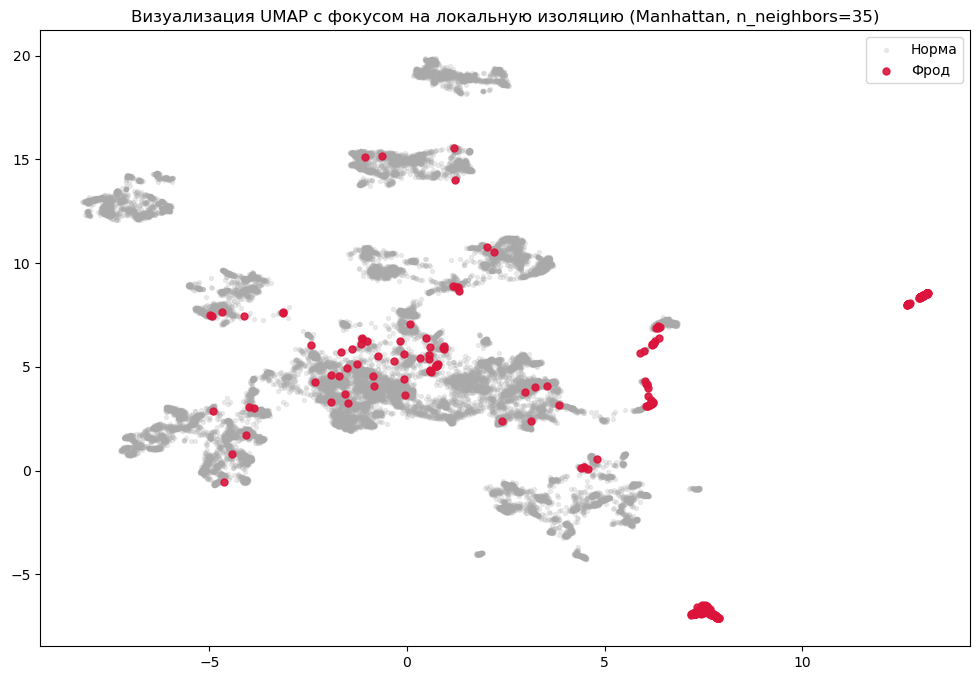

In [25]:
# Донастройка метрик туда-сюда пока не получится красивая картинка.

reducer_extreme = umap.UMAP(
    n_neighbors=35,       # Фокус на локальных соседях (отсекаем глобальные связи)
    min_dist=0.1,         # Плотная упаковка точек в кластеры
    metric='manhattan',   # Более чувствительная метрика для 30 признаков PCA
    # random_state=42       # random_state удалялся для параллелизма, оставлен в
)
X_embedded_extreme = reducer_extreme.fit_transform(X_sub_scaled)

# Отрисовка
plt.figure(figsize=(12, 8))
plt.scatter(X_embedded_extreme[y_sub == 0, 0], X_embedded_extreme[y_sub == 0, 1], alpha=0.2, s=8, color='darkgray', label='Норма')
plt.scatter(X_embedded_extreme[y_sub == 1, 0], X_embedded_extreme[y_sub == 1, 1], alpha=0.9, s=25, color='crimson', label='Фрод')
plt.title("Визуализация UMAP с фокусом на локальную изоляцию (Manhattan, n_neighbors=35)")
plt.legend()
plt.show()

Запуск алгоритма несколько раз с разным набором параметров, привёл к формированию итогового изображения, где чётко видно два отдельных от общей группы операций кластера мошенических действий и два таких кластера близко к норме, но UMAP отделил и их.



## Итоги

В ходе выполнения проекта был разработан универсальный многоуровневый ансамблевый пайплайн (AdvancedAnomalyPipeline), объединяющий геометрические, плотностные, линейные, деревянные и нейросетевые (Autoencoder/VAE) методы детекции аномалий.

Использование экспертной оценки загрязненности данных (contamination = 0.17%) позволило ювелирно настроить пороги отсечения каждого алгоритма без учителя.

Первичный анализ структуры данных и итоговая визуализация с помощью локально-оптимизированного алгоритма UMAP (Manhattan, n_neighbors=35) доказали, что аномалии в датасете Credit Card Fraud не являются однородными. Они распадаются как минимум на 4 выраженных математических паттерна (два изолированных внешних кластера и два скрытых центральных сгустка высокой плотности).

Эксперимент подтвердил, что разработанный вложенный пайплайн успешно страхует изолированные недостатки одиночных моделей, обеспечивая максимальную разделимость классов и высокую полноту детекции мошеннических операций.